In [15]:
using CSV
using DataFrames
using CairoMakie
using LsqFit
using Statistics

In [2]:
#Daten aus Datei nehmen
df = CSV.read("Messdaten_Pulverdiffraktonomie/Probe3_Messdaten.xye", DataFrame, delim=' ', ignorerepeated=true, 
skipto=2, header=["zwei_theta", "I", "ΔI"])

zwei_θ = df.zwei_theta
I = df.I
ΔI = df.ΔI;



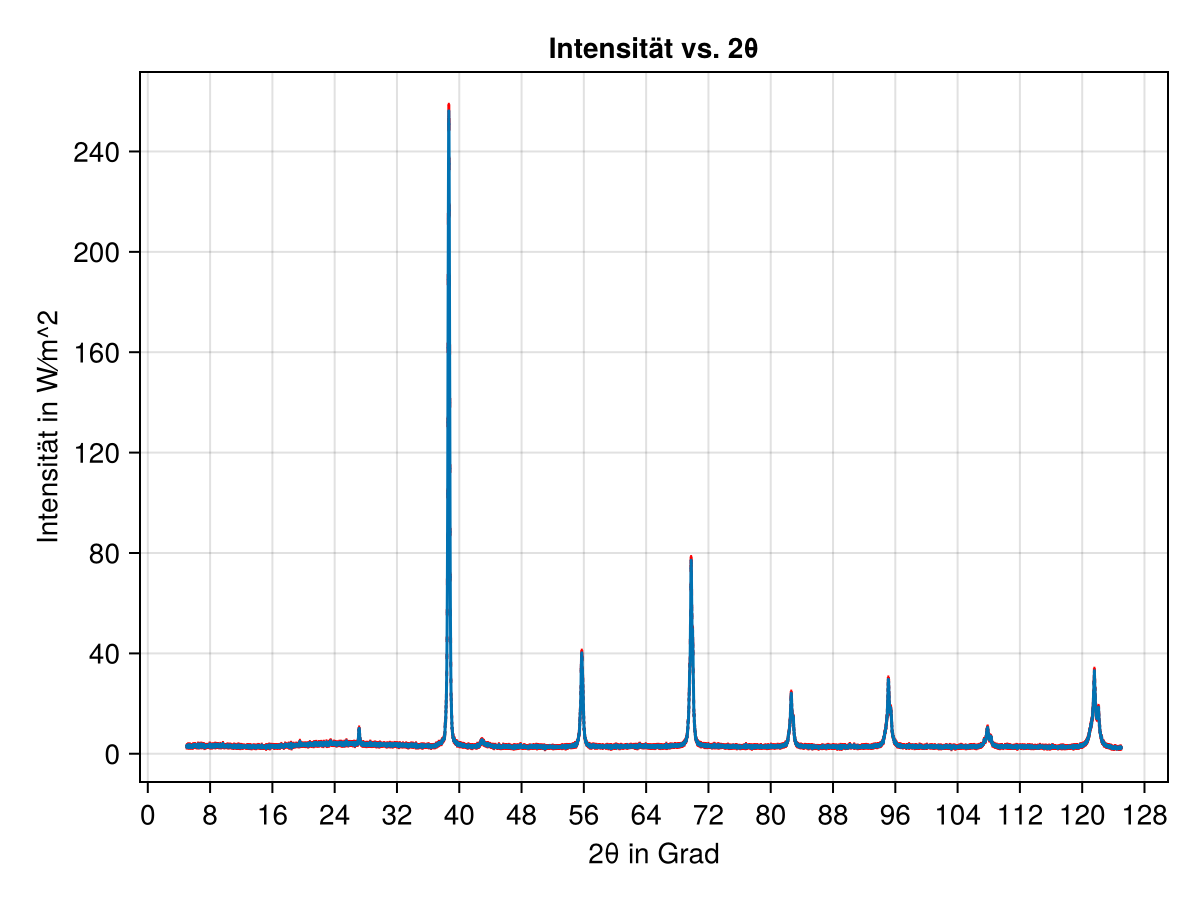

In [3]:
#Intensität vs 2theta
fig, ax, eb = errorbars(zwei_θ, I, ΔI, color = :red, whiskerwidth = 1)
scatterlines!(ax, zwei_θ, I, markersize = 2)

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)
ax.title = "Intensität vs. 2θ"
ax.xlabel = "2θ in Grad"
ax.ylabel = "Intensität in W⁄m^2"
fig

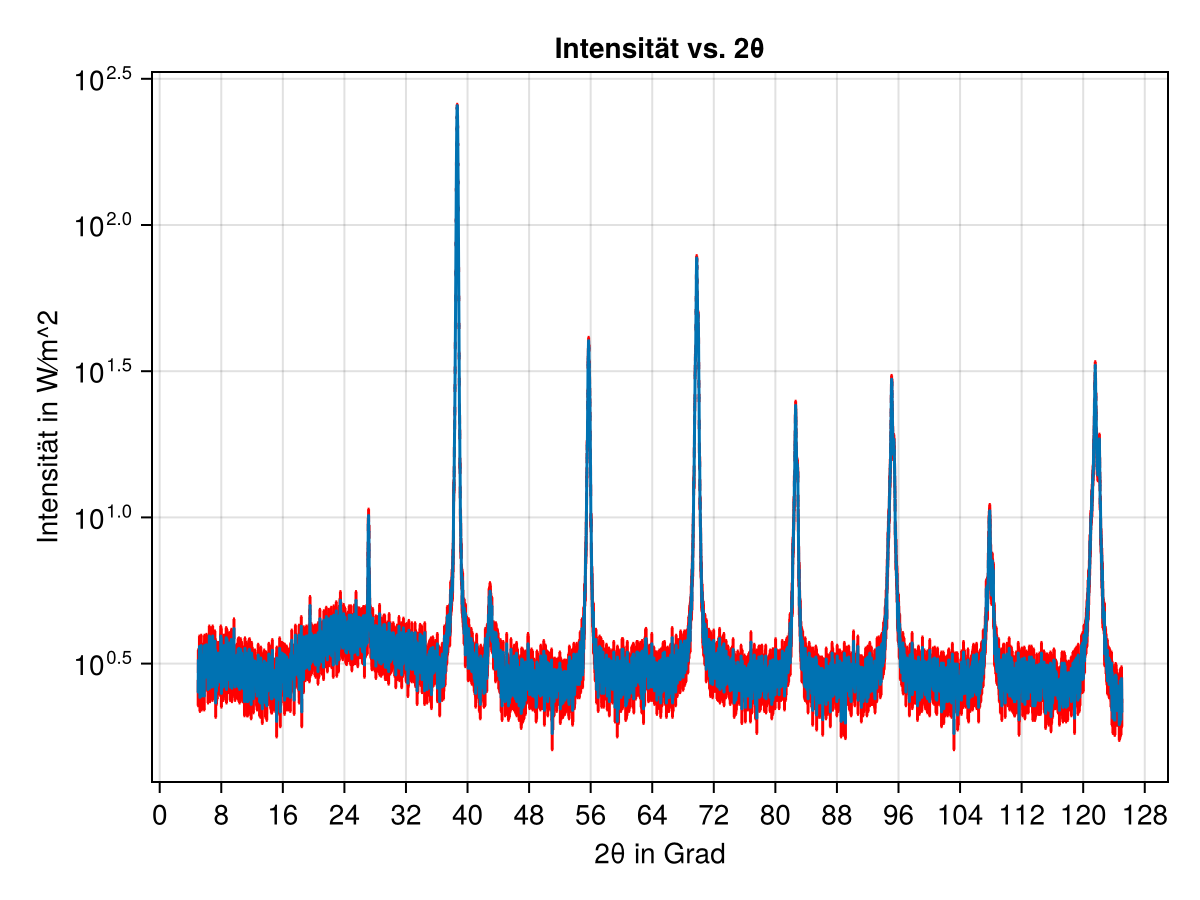

In [4]:
#Intensität mit log-skala
fig, ax, eb = errorbars(zwei_θ, I, ΔI, color = :red, whiskerwidth = 1)
scatterlines!(ax, zwei_θ, I, markersize = 2)

ax.xticks = LinearTicks(20)
ax.yscale = log10
#ax.xscale = log10
ax.title = "Intensität vs. 2θ"
ax.xlabel = "2θ in Grad"
ax.ylabel = "Intensität in W⁄m^2"
fig

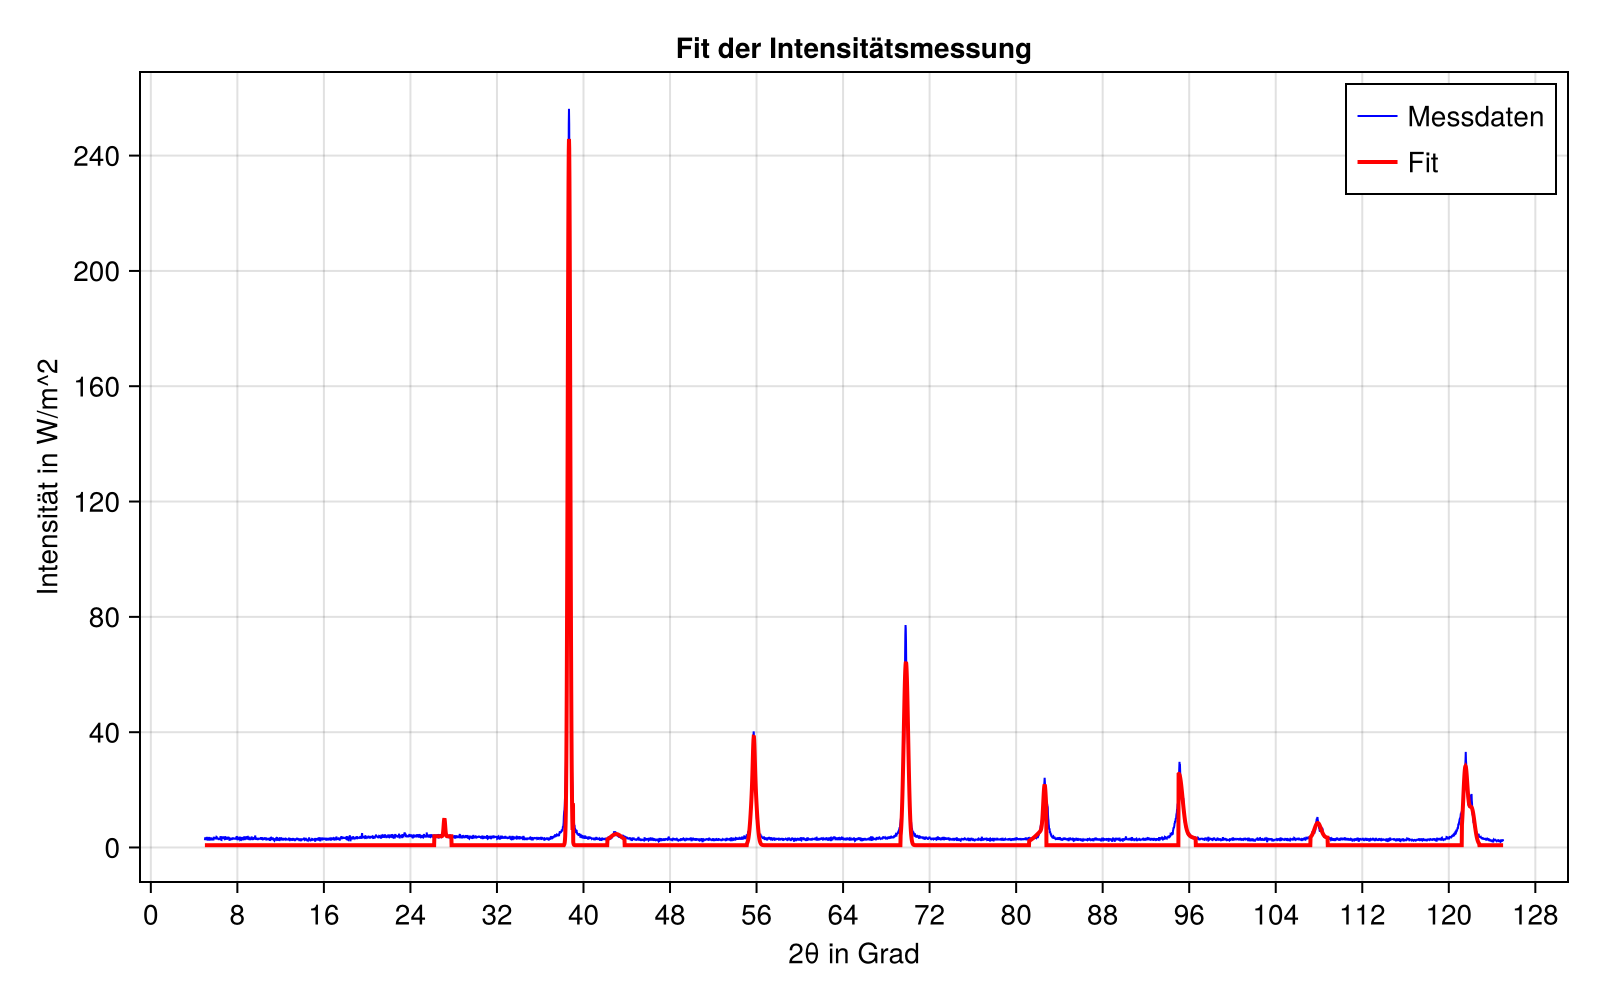

In [8]:
function doppel_gauß_einzeln(x, p)
    g1 = p[1] .* exp.(-(x .- p[2]).^2 ./ (2 .* p[3]^2))
    g2 = (p[1] / 2) .* exp.(-(x .- p[4]).^2 ./ (2 .* p[5]^2))
    return g1 .+ g2
end

# 1. Liste an allen ungefähren Positionen der peaks die gefittet werden sollen
peak_zentren = [27, 39, 43, 55.9, 70.1, 82, 95.8, 108, 122.01] 

#Fester Wert für den Boden
fit_ergebnisse = []
untergrund_fest = 0.8 

# Jeden Peak einzeln fitten in einer Schleife
for zentrum in peak_zentren
    # Für den schwierigen Peak bei 45.2 nutzen wir ein etwas weiteres Fenster,
    # um den gesamten Ausläufer mitzunehmen.
    f_breite = (zentrum == 45.2) ? 1.0 : 0.8
    bereich = (zwei_θ .> zentrum - f_breite) .& (zwei_θ .< zentrum + f_breite)
    
    x_sub = zwei_θ[bereich]
    y_sub = I[bereich]
    
    if isempty(x_sub) continue end
    
    # Standard-Startwerte
    amp_start = max(0.1, maximum(y_sub) - untergrund_fest)
    p0 = [amp_start, zentrum, 0.05, zentrum + 0.04, 0.05] 
    
    # Spezialbehandlung für den Problempeak bei 45.2° ohne starre Box-Grenzen,
    # aber mit extrem defensiven Startwerten für die Peak-Breite (sigma)
    if zentrum == 45.2
        # Wir geben ihm eine realistischere, etwas größere Startbreite (0.08 statt 0.03)
        # und setzen das Zentrum von Kα1 exakt auf den höchsten Punkt im Teilfenster
        x_max_lokal = x_sub[argmax(y_sub)]
        p0 = [maximum(y_sub) - untergrund_fest, x_max_lokal, 0.08, x_max_lokal + 0.05, 0.08]
    end
    
    model_lokal(x, p) = doppel_gauß_einzeln(x, p) .+ untergrund_fest
    
    try
        if zentrum == 45.2
            # Wir nutzen etwas großzügigere Grenzen, die nur das Ausbrechen ins Unendliche verhindern,
            # aber der Form (Breite) vollkommene Freiheit lassen:
            untere_grenze = [1.0,  44.5,  0.01,  44.5,  0.01]
            obere_grenze  = [200.0, 46.0,  0.3,   46.0,  0.3]
            
            fit = curve_fit(model_lokal, x_sub, y_sub, p0, lower=untere_grenze, upper=obere_grenze)
        else
            fit = curve_fit(model_lokal, x_sub, y_sub, p0)
        end
        
        p_opt = coef(fit)
        
        if p_opt[1] > 1.0 
            push!(fit_ergebnisse, (params=p_opt, bereich=bereich))
        end
    catch e
        println("Fit fehlgeschlagen bei Zentrum $zentrum")
    end
end

# 4. Gesamtkurve zusammensetzen
y_gesamt = fill(untergrund_fest, length(zwei_θ))

for fit in fit_ergebnisse
    y_peak = doppel_gauß_einzeln(zwei_θ, fit.params)
    y_peak[.!fit.bereich] .= 0.0
    global y_gesamt += y_peak
end

# 5. Plotten
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], 
    title = "Fit der Intensitätsmessung",
    xlabel = "2θ in Grad",
    ylabel = "Intensität in W/m^2"
)

lines!(ax, zwei_θ, I, color = :blue, linewidth = 1, label = "Messdaten")
lines!(ax, zwei_θ, y_gesamt, color = :red, linewidth = 2, label = "Fit")

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)

axislegend(ax)
fig


In [6]:
println("   POSITIONEN DER GEFITTETEN PEAKS (2θ in Grad)")


for (i, fit) in enumerate(fit_ergebnisse)
    # Runden auf 4 Nachkommastellen für die physikalische Präzision
    pos_ka1 = round(fit.params[2], digits=4)
    pos_ka2 = round(fit.params[4], digits=4)
    
    println("Peak #$i:   Kα1 = $(pos_ka1)°   |   Kα2 = $(pos_ka2)°")
end

   POSITIONEN DER GEFITTETEN PEAKS (2θ in Grad)
Peak #1:   Kα1 = 27.1403°   |   Kα2 = 26.1391°
Peak #2:   Kα1 = 38.6599°   |   Kα2 = 39.0207°
Peak #3:   Kα1 = 43.0226°   |   Kα2 = 45.3776°
Peak #4:   Kα1 = 55.7507°   |   Kα2 = 55.7453°
Peak #5:   Kα1 = 69.8113°   |   Kα2 = 70.1124°
Peak #6:   Kα1 = 82.6303°   |   Kα2 = 83.3212°
Peak #7:   Kα1 = 95.0562°   |   Kα2 = 91.284°
Peak #8:   Kα1 = 107.8793°   |   Kα2 = 108.494°
Peak #9:   Kα1 = 121.5266°   |   Kα2 = 122.0988°


In [ ]:
#Die Ergebnisse des Fits hängen ab von den Startpositionen die man dem Code gibt. Ich habe versucht sie so zu wählen, dass 
#der Fir möglichst genau die Peaks überldeckt. 



   POSITIONEN DER GEFITTETEN PEAKS (2θ in Grad)
------------------------------------------------------------------
Peak #1:   Kα1 = 27.1403° ± 0.0025°   |   Kα2 = 26.1391° ± 1.716716691e6°
Peak #2:   Kα1 = 38.6599° ± 0.0017°   |   Kα2 = 39.0207° ± 0.001°
Peak #3:   Kα1 = 42.8539° ± 0.0414°   |   Kα2 = 43.7045° ± 0.0669°
Peak #4:   Kα1 = 55.7507° ± 0.0068°   |   Kα2 = 55.7453° ± 0.0081°
Peak #5:   Kα1 = 69.8091° ± 0.0053°   |   Kα2 = 69.805° ± 0.0173°
Peak #6:   Kα1 = 82.6303° ± 0.004°   |   Kα2 = 83.3212° ± 0.2346°
Peak #7:   Kα1 = 95.0562° ± 0.0456°   |   Kα2 = 91.284° ± 6.2022°
Peak #8:   Kα1 = 107.8793° ± 0.0222°   |   Kα2 = 108.494° ± 2.47°
Peak #9:   Kα1 = 121.5266° ± 0.0094°   |   Kα2 = 122.0988° ± 0.0277°
------------------------------------------------------------------



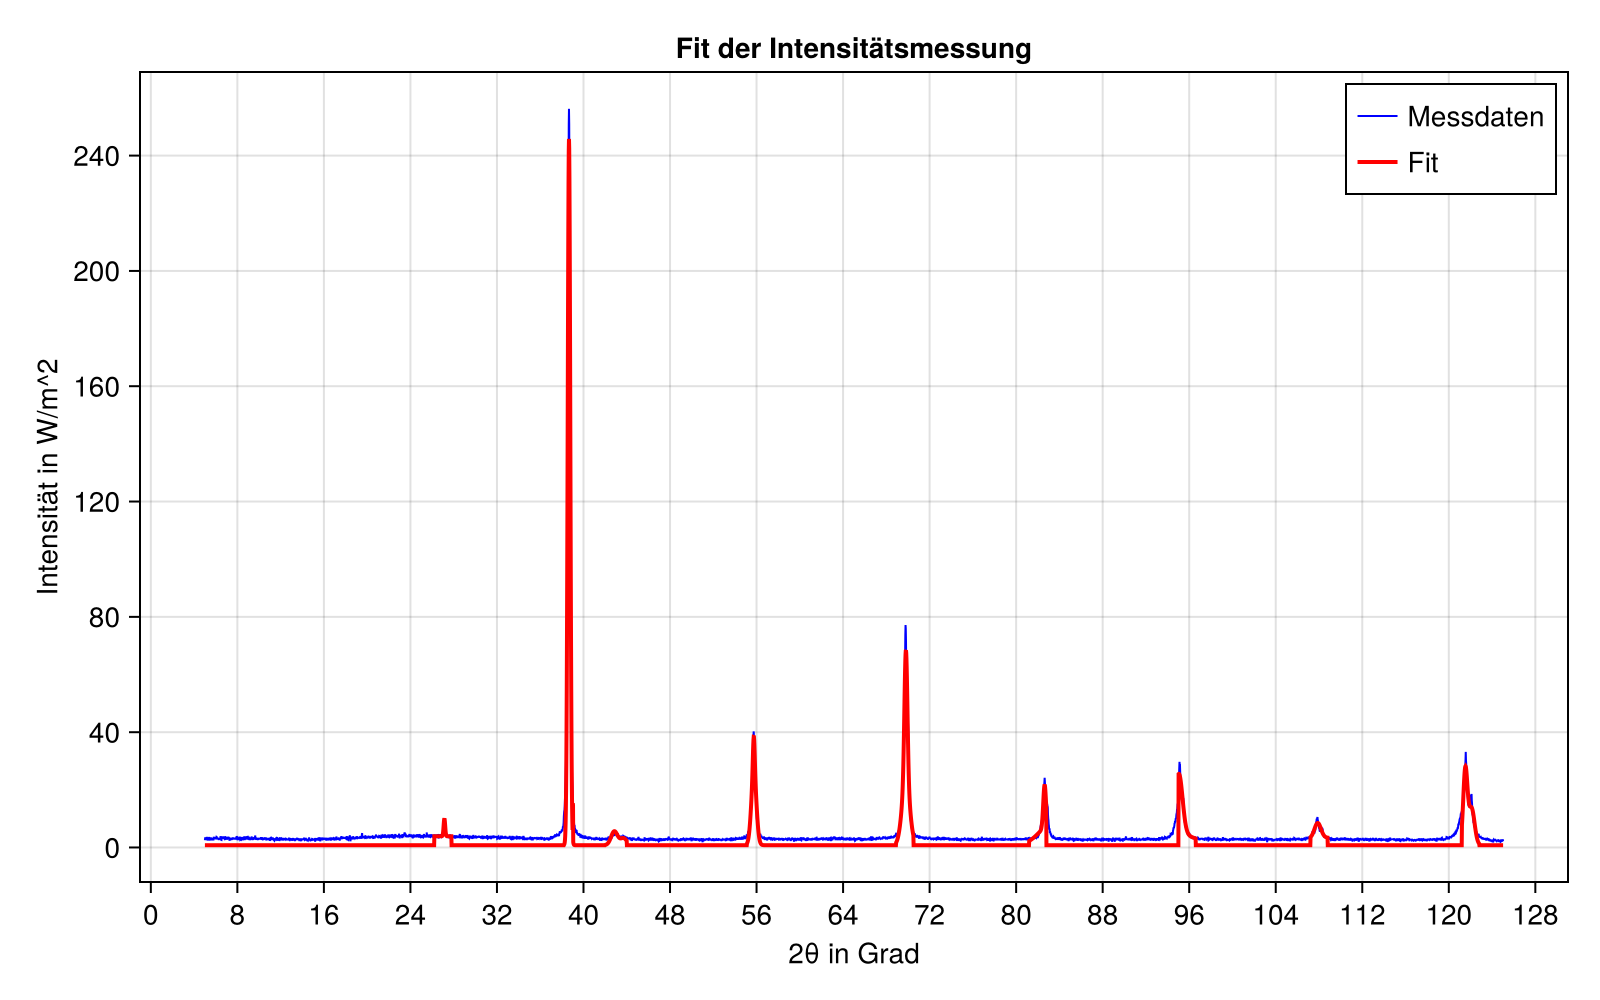

In [ ]:


function doppel_gauß_einzeln(x, p)
    g1 = p[1] .* exp.(-(x .- p[2]).^2 ./ (2 .* p[3]^2))
    g2 = (p[1] / 2) .* exp.(-(x .- p[4]).^2 ./ (2 .* p[5]^2))
    return g1 .+ g2
end

# 1. Liste an allen ungefähren Positionen der peaks die gefittet werden sollen
peak_zentren = [27, 39, 43, 55.9, 69.7, 82, 95.8, 108, 122.01] 

# Fester Wert für den Boden
fit_ergebnisse = []
untergrund_fest = 0.8 

# Jeden Peak einzeln fitten in einer Schleife
for zentrum in peak_zentren
    # Für den schwierigen Peak bei 43 nutzen wir ein etwas weiteres Fenster,
    # um den gesamten Ausläufer mitzunehmen.
    f_breite = (zentrum == 43) ? 1.0 : 0.8
    bereich = (zwei_θ .> zentrum - f_breite) .& (zwei_θ .< zentrum + f_breite)
    
    x_sub = zwei_θ[bereich]
    y_sub = I[bereich]
    
    if isempty(x_sub) continue end
    
    # Standard-Startwerte
    amp_start = max(0.1, maximum(y_sub) - untergrund_fest)
    p0 = [amp_start, zentrum, 0.05, zentrum + 0.04, 0.05] 
    
    # Spezialbehandlung für den Problempeak bei 43° ohne starre Box-Grenzen,
    # aber mit extrem defensiven Startwerten für die Peak-Breite (sigma)
    if zentrum == 43
        # Wir geben ihm eine realistischere, etwas größere Startbreite (0.08 statt 0.03)
        # und setzen das Zentrum von Kα1 exakt auf den höchsten Punkt im Teilfenster
        x_max_lokal = x_sub[argmax(y_sub)]
        p0 = [maximum(y_sub) - untergrund_fest, x_max_lokal, 0.08, x_max_lokal + 0.05, 0.08]
    end
    
    model_lokal(x, p) = doppel_gauß_einzeln(x, p) .+ untergrund_fest
    
    try
        if zentrum == 43
            # Wir nutzen etwas großzügigere Grenzen, die nur das Ausbrechen ins Unendliche verhindern,
            # aber der Form (Breite) vollkommene Freiheit lassen:
            untere_grenze = [0.1,  42.0,  0.01,  42.0,  0.01]
            obere_grenze  = [200.0, 44.0,  0.3,   44.0,  0.3]
            
            fit = curve_fit(model_lokal, x_sub, y_sub, p0, lower=untere_grenze, upper=obere_grenze)
        else
            fit = curve_fit(model_lokal, x_sub, y_sub, p0)
        end
        
        p_opt = coef(fit)
        p_err = stderror(fit)  # Fehler für alle Parameter bestimmen
        
        # Sicherstellen, dass der Peak über dem Rauschen liegt
        if p_opt[1] > 0.1 
            push!(fit_ergebnisse, (params=p_opt, errors=p_err, bereich=bereich)) 
        end
    catch e
        println("Fit fehlgeschlagen bei Zentrum $zentrum")
    end
end

# 4. Gesamtkurve zusammensetzen
y_gesamt = fill(untergrund_fest, length(zwei_θ))

for fit in fit_ergebnisse
    y_peak = doppel_gauß_einzeln(zwei_θ, fit.params)
    y_peak[.!fit.bereich] .= 0.0
    global y_gesamt += y_peak
end

# 5. Textausgabe der gefitteten Peakpositionen inklusive Standardfehler
println("\n   POSITIONEN DER GEFITTETEN PEAKS (2θ in Grad)")
println("------------------------------------------------------------------")
for (i, fit) in enumerate(fit_ergebnisse)
    # Runden auf 4 Nachkommastellen für die physikalische Präzision
    pos_ka1 = round(fit.params[2], digits=4)
    pos_ka2 = round(fit.params[4], digits=4)
    
    err_ka1 = round(fit.errors[2], digits=4)
    err_ka2 = round(fit.errors[4], digits=4)
    
    println("Peak #$i:   Kα1 = $(pos_ka1)° ± $(err_ka1)°   |   Kα2 = $(pos_ka2)° ± $(err_ka2)°")
end
println("------------------------------------------------------------------\n")

# 6. Plotten
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], 
    title = "Fit der Intensitätsmessung",
    xlabel = "2θ in Grad",
    ylabel = "Intensität in W/m^2"
)

lines!(ax, zwei_θ, I, color = :blue, linewidth = 1, label = "Messdaten")
lines!(ax, zwei_θ, y_gesamt, color = :red, linewidth = 2, label = "Fit")

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)

axislegend(ax)
fig